# Which missing links should we expect?

You're handed a social network with most of its connections, but a few have been
deliberately hidden. Your job: rank every *non-edge* in the graph by how likely
it is to be one of the hidden ones.

This is **link prediction** — task #2 in the NS20 framing (slide 6). It powers
"People you may know" on every social platform, drug-target predictions in
biology, and citation suggestions in academic search. The principle is the
same everywhere: turn a pair of nodes into a feature vector, score each pair,
sort by score.

The interesting question for this notebook isn't "can we do it?" — it's
**"how far can simple, hand-designed features take us?"** The same NS20 lesson
as the node-classification notebook, this time on *pairs* of nodes instead of
single nodes.

## The testbed: who-talks-to-whom in *Les Misérables*

We use a classic pedagogical dataset: the co-appearance graph of characters in
Victor Hugo's *Les Misérables*. Two characters are connected if they appear in
the same chapter at least once. It comes built-in with NetworkX, so there's
nothing to download.

It's small enough to *see* — 77 characters, 254 connections — but dense
enough that the heuristics we'll build can find real signal.

In [1]:
from netsci_utils import *
set_seeds()
%matplotlib inline

import random
import pandas as pd
from sklearn.metrics import roc_auc_score

G = nx.les_miserables_graph()
G = nx.Graph(G)            # make sure it's plain undirected, not weighted MultiGraph

print(f"  nodes : {G.number_of_nodes()}")
print(f"  edges : {G.number_of_edges()}")
print(f"  avg degree : {2*G.number_of_edges()/G.number_of_nodes():.2f}")
print(f"  clustering coefficient (avg) : {nx.average_clustering(G):.3f}")


  nodes : 77
  edges : 254
  avg degree : 6.60
  clustering coefficient (avg) : 0.573


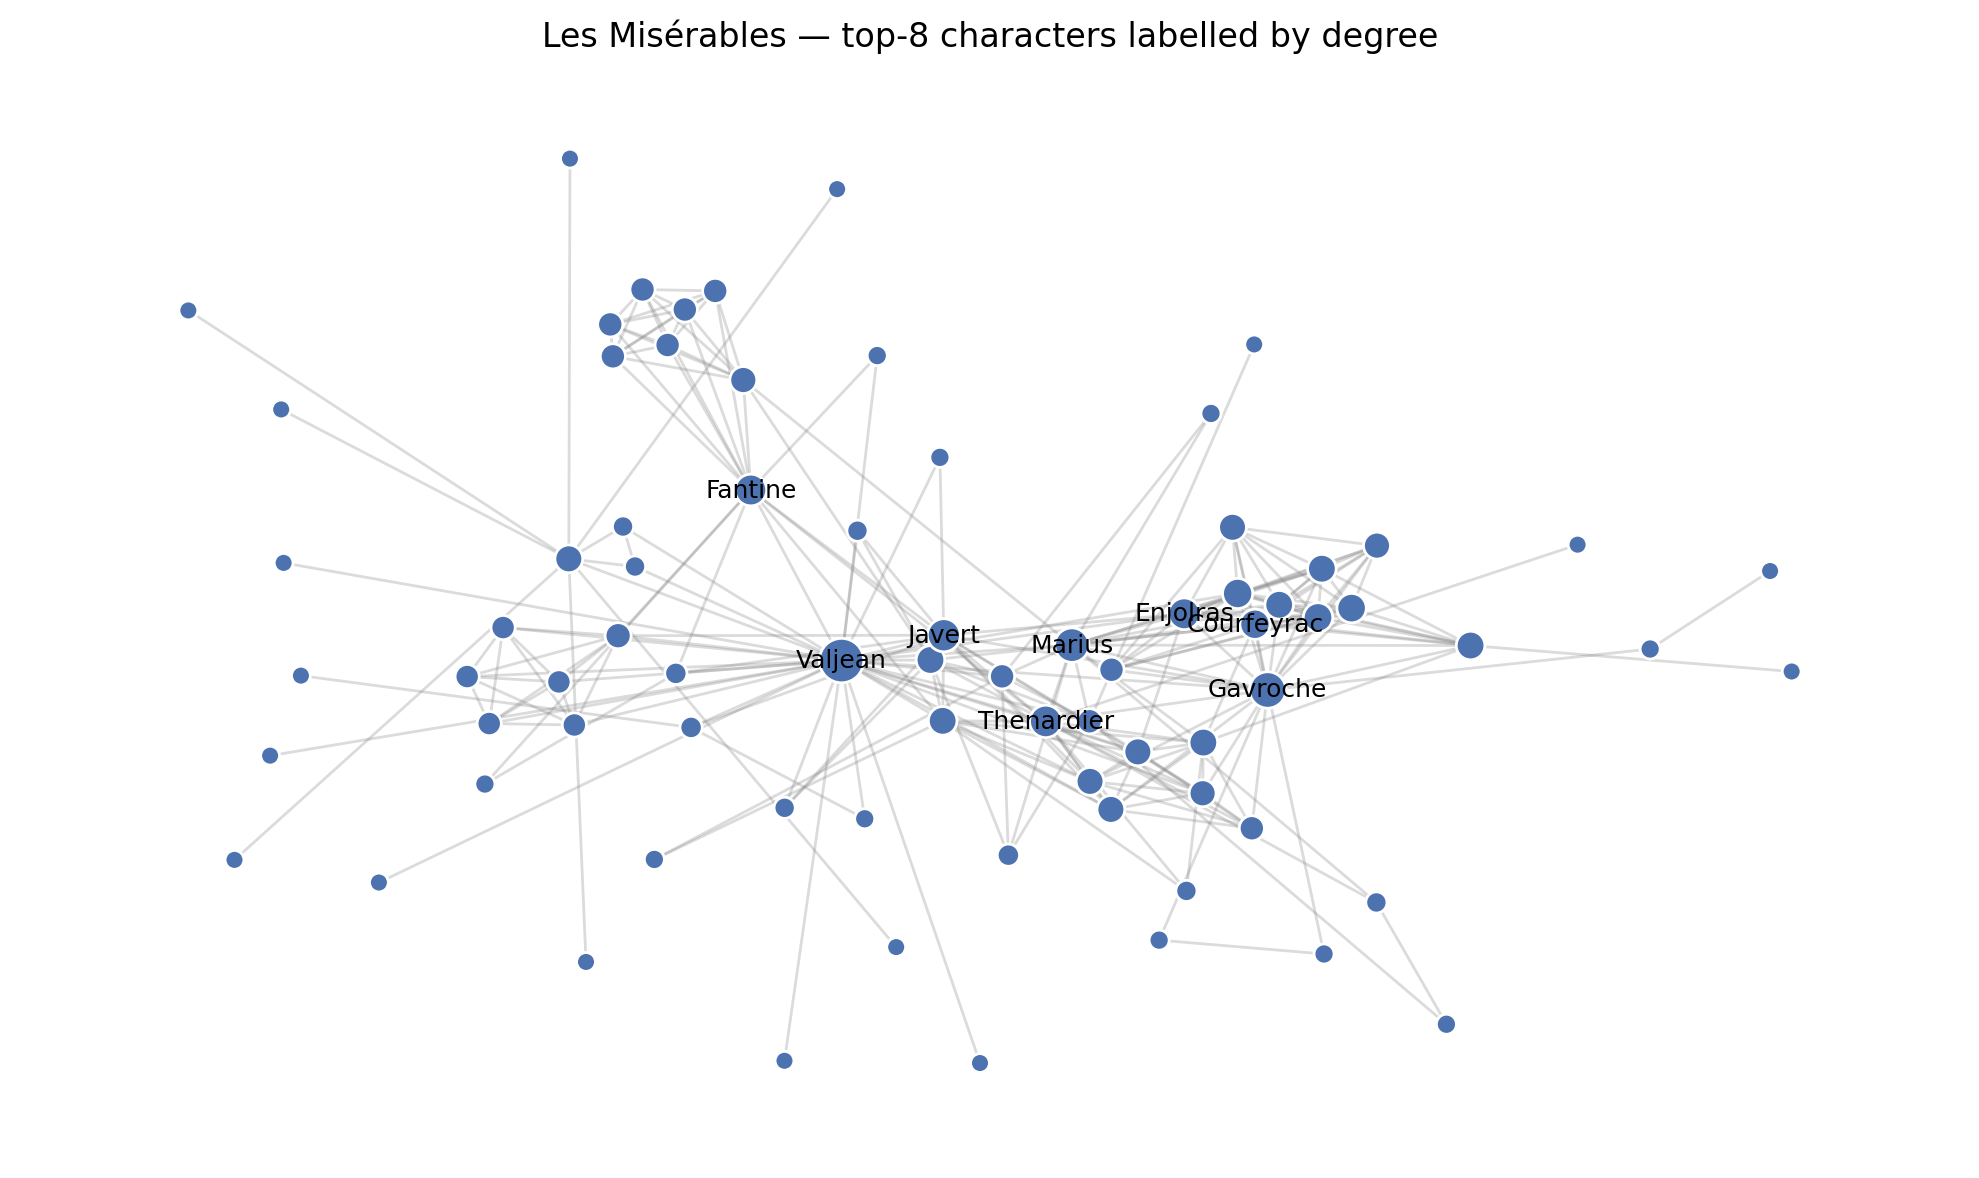

In [2]:
# Quick visual — spring layout, node size = degree
plt.figure(figsize=FIGURE_SIZE)
pos = nx.spring_layout(G, seed=RANDOM_SEED, k=0.5)
deg = dict(G.degree())
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color=EDGE_COLOR)
nx.draw_networkx_nodes(G, pos,
    node_color=NODE_COLOR,
    node_size=[40 + 6*deg[n] for n in G.nodes()],
    edgecolors="white", linewidths=1)
# Label only the highest-degree characters
top = sorted(G.nodes(), key=deg.get, reverse=True)[:8]
nx.draw_networkx_labels(G, pos, labels={n:n for n in top}, font_size=9)
plt.axis("off"); plt.title("Les Misérables — top-8 characters labelled by degree")
plt.tight_layout(); plt.show()


Valjean is the obvious hub (he interacts with almost everyone). Beyond
him there are several smaller groups — the bishop's circle, the Thénardier
family, the Friends of the ABC. That community structure is *exactly* what
makes link prediction tractable: people in the same group are more likely to
co-appear, even if they haven't yet.

## The link-prediction recipe

We don't have any "future" Les Mis to validate against, so we manufacture the
prediction problem ourselves:

1. **Hide some real edges.** Pick a random 20 % of the edges in `G`, remove
   them, and call those the **positive test set** — the links we want to
   recover.
2. **Sample fake edges.** Pick the same number of *non-edges* (pairs of nodes
   that have never co-appeared) at random — the **negative test set**.
3. **Score every test pair** with a heuristic computed *only on the visible
   graph* `G_obs` (the one with the held-out edges removed).
4. **Evaluate.** A good heuristic gives positives higher scores than
   negatives. We measure that with the **AUC** of the score distribution.

In [3]:
edges = list(G.edges())
random.shuffle(edges)
n_test = int(len(edges) * 0.20)
test_pos = edges[:n_test]
train_edges = edges[n_test:]

G_obs = nx.Graph()
G_obs.add_nodes_from(G.nodes())
G_obs.add_edges_from(train_edges)

# Negative samples: random non-edges that are also non-edges in G_obs
nodes = list(G.nodes())
existing = set(G.edges()) | {(v,u) for u,v in G.edges()}
test_neg = []
while len(test_neg) < n_test:
    u, v = random.sample(nodes, 2)
    if (u,v) not in existing and (v,u) not in existing:
        test_neg.append((u, v))

print(f"  visible edges (G_obs): {G_obs.number_of_edges()}")
print(f"  hidden positives    : {len(test_pos)}")
print(f"  sampled negatives   : {len(test_neg)}")


  visible edges (G_obs): 204
  hidden positives    : 50
  sampled negatives   : 50


Important detail: we compute every score *on `G_obs`*, never on the full
graph. If you accidentally peek at the test edges while computing features,
your AUC will look amazing and mean nothing.

## Four heuristics — what should make a non-edge look like a missing edge?

The intuition behind nearly every classical link-prediction score: **two
people who share friends are likely to know each other.** Each of the four
classics below operationalises that intuition slightly differently.

| Score | Formula | What it captures |
|---|---|---|
| **CN — Common Neighbours** | $\|N(u) \cap N(v)\|$ | Raw count of shared friends |
| **Jaccard** | $\|N(u) \cap N(v)\| / \|N(u) \cup N(v)\|$ | CN normalised by neighbourhood size — penalises big hubs |
| **Adamic–Adar** | $\sum_{w \in N(u)\cap N(v)} 1/\log\,\deg(w)$ | Rare common friends count more than popular ones |
| **PA — Preferential Attachment** | $\deg(u) \cdot \deg(v)$ | "Hubs attract more hubs" — *no neighbour overlap needed* |

The first three look at the *overlap* of neighbours. The last one ignores
overlap entirely and bets on raw popularity. Watch how differently they
behave.

In [4]:
def common_neighbors(G, u, v):
    return len(set(G.neighbors(u)) & set(G.neighbors(v)))

def jaccard(G, u, v):
    nu, nv = set(G.neighbors(u)), set(G.neighbors(v))
    union = nu | nv
    return len(nu & nv) / len(union) if union else 0.0

def adamic_adar(G, u, v):
    common = set(G.neighbors(u)) & set(G.neighbors(v))
    s = 0.0
    for w in common:
        d = G.degree(w)
        if d > 1:
            s += 1.0 / np.log(d)
    return s

def preferential_attachment(G, u, v):
    return G.degree(u) * G.degree(v)

# Sanity check on a single, intuitive pair
u, v = "Cosette", "Marius"
print(f"Pair ({u}, {v}) — are they connected in G_obs? "
      f"{G_obs.has_edge(u, v)}")
print(f"  common_neighbors        = {common_neighbors(G_obs, u, v)}")
print(f"  jaccard                 = {jaccard(G_obs, u, v):.3f}")
print(f"  adamic_adar             = {adamic_adar(G_obs, u, v):.3f}")
print(f"  preferential_attachment = {preferential_attachment(G_obs, u, v)}")


Pair (Cosette, Marius) — are they connected in G_obs? True
  common_neighbors        = 2
  jaccard                 = 0.105
  adamic_adar             = 0.937
  preferential_attachment = 90


The exact numbers depend on which edges happened to be hidden, but the
*pattern* is the same every time you re-run: Cosette and Marius live in the
same neighbourhood of the graph, so they share several common contacts —
their CN is non-trivial, their Jaccard is moderate, their AA gets boosted
by less-popular shared friends, and PA reflects the modest degree of both.

Now contrast that with a pair from completely separate parts of the
network:

In [5]:
# Two characters from very different storylines
u, v = "Napoleon", "Champtercier"
print(f"Pair ({u}, {v})")
print(f"  common_neighbors        = {common_neighbors(G_obs, u, v)}")
print(f"  jaccard                 = {jaccard(G_obs, u, v):.3f}")
print(f"  adamic_adar             = {adamic_adar(G_obs, u, v):.3f}")
print(f"  preferential_attachment = {preferential_attachment(G_obs, u, v)}")


Pair (Napoleon, Champtercier)
  common_neighbors        = 0
  jaccard                 = 0.000
  adamic_adar             = 0.000
  preferential_attachment = 0


Zero shared friends → CN, Jaccard, AA all collapse to zero. PA still
returns a small product, because both nodes have *some* degree, but it's
clearly weak. That's the whole game: a heuristic should give *high* scores
to non-edges that look like they should be edges, and *low* scores to
non-edges that don't.

## Evaluate with AUC

We score every test pair (positives + negatives) with each heuristic, then
compute the AUC: the probability that a random positive scores higher than
a random negative. AUC = 1.0 is perfect; 0.5 is random guessing.

In [6]:
def auc_for(score_fn, G_obs, pos, neg):
    s_pos = [score_fn(G_obs, u, v) for u, v in pos]
    s_neg = [score_fn(G_obs, u, v) for u, v in neg]
    y      = [1]*len(s_pos) + [0]*len(s_neg)
    scores =  s_pos + s_neg
    return roc_auc_score(y, scores)

results = {
    "CN — common neighbours"    : auc_for(common_neighbors,         G_obs, test_pos, test_neg),
    "Jaccard"                   : auc_for(jaccard,                  G_obs, test_pos, test_neg),
    "Adamic–Adar"               : auc_for(adamic_adar,              G_obs, test_pos, test_neg),
    "PA — preferential attach." : auc_for(preferential_attachment,  G_obs, test_pos, test_neg),
}
for k, v in results.items():
    print(f"  {k:30s}  AUC = {v:.3f}")


  CN — common neighbours          AUC = 0.869
  Jaccard                         AUC = 0.861
  Adamic–Adar                     AUC = 0.878
  PA — preferential attach.       AUC = 0.779


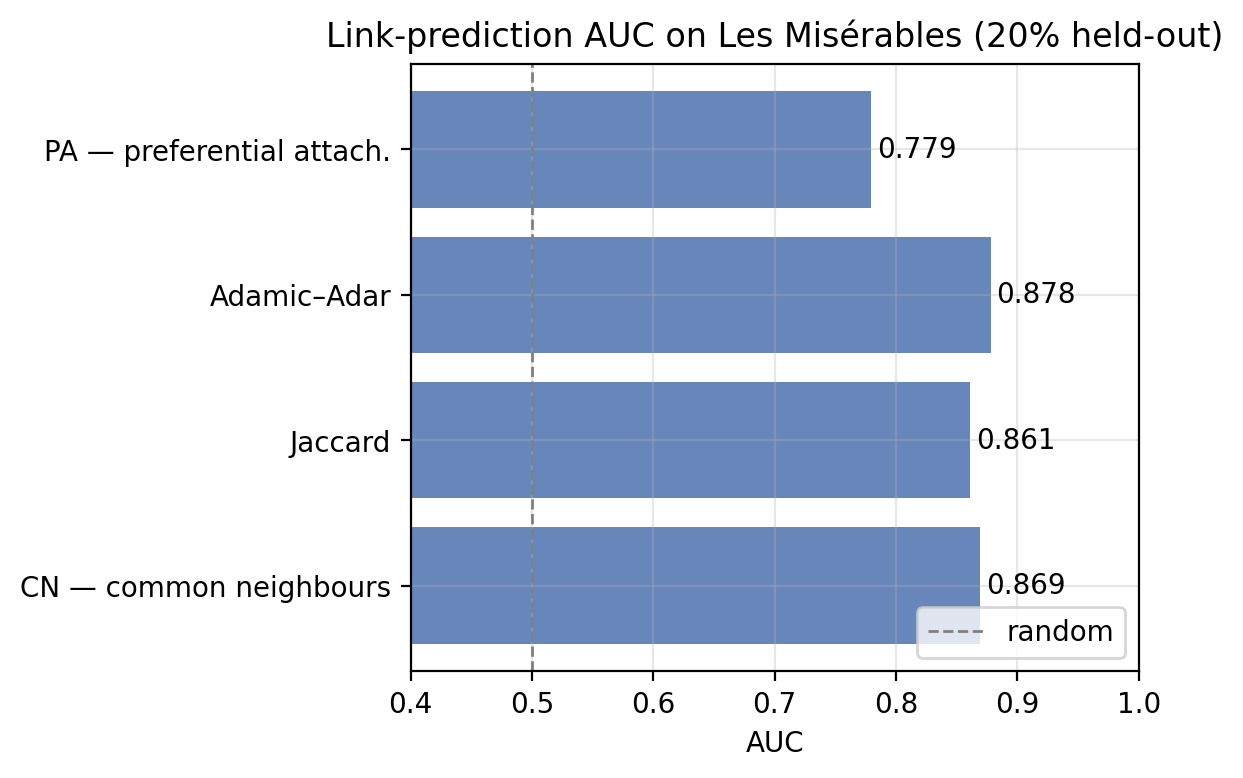

In [7]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
labels = list(results.keys())
vals   = [results[k] for k in labels]
ax.barh(labels, vals, color=NODE_COLOR, alpha=0.85)
ax.axvline(0.5, color="grey", ls="--", lw=1, label="random")
for i, v in enumerate(vals):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10)
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("AUC")
ax.set_title("Link-prediction AUC on Les Misérables (20% held-out)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


Three observations worth making explicit:

* **All four heuristics beat random** (the dashed line at 0.5). Even the
  crudest one — common neighbours — has real predictive power on this graph.
* **Adamic–Adar usually wins** by a small margin. The intuition: if two
  characters share *Valjean* as a friend, that's not informative (he's
  everyone's friend), but if they share a niche character like *Mabeuf*, that
  is. AA encodes that downweighting via $1/\log \deg$.
* **Preferential attachment is the weakest** of the four despite needing no
  neighbour overlap at all — because it makes high-degree nodes look like
  the answer to *every* query, which is wrong most of the time.

Run the notebook again with a different seed and the absolute numbers
will shift by a few percentage points, but this ordering — AA ≈ CN ≥
Jaccard > PA — is robust on Les Misérables.

## Where the heuristics fail

The shared-friends idea has one obvious blind spot: **what if there are no
shared friends?** Every neighbourhood-overlap score collapses to zero on
those pairs, even though the link might be perfectly plausible
("colleague-of-colleague" effects, distant friendships, etc.).

Let's see how many test positives have zero common neighbours in the
observed graph — these are pairs that *every* CN/Jaccard/AA score is silently
giving up on.

In [8]:
zero_cn_pos = [(u, v) for u, v in test_pos if common_neighbors(G_obs, u, v) == 0]
zero_cn_neg = [(u, v) for u, v in test_neg if common_neighbors(G_obs, u, v) == 0]

print(f"Positives with 0 common neighbours: {len(zero_cn_pos)} / {len(test_pos)}")
print(f"Negatives with 0 common neighbours: {len(zero_cn_neg)} / {len(test_neg)}")
print()
print("Examples of positives the local heuristics can't distinguish from random:")
for u, v in zero_cn_pos[:5]:
    print(f"  {u:20s} ↔ {v:20s}  "
          f"deg(u)={G_obs.degree(u):2d}  deg(v)={G_obs.degree(v):2d}")


Positives with 0 common neighbours: 9 / 50
Negatives with 0 common neighbours: 40 / 50

Examples of positives the local heuristics can't distinguish from random:
  Myriel               ↔ Champtercier          deg(u)= 7  deg(v)= 0
  Fauchelevent         ↔ Gribier               deg(u)= 3  deg(v)= 0
  Myriel               ↔ CountessDeLo          deg(u)= 7  deg(v)= 0
  Tholomyes            ↔ Marius                deg(u)= 7  deg(v)=15
  Mabeuf               ↔ MotherPlutarch        deg(u)= 9  deg(v)= 0


These are the pairs that need *something more* than local overlap.
Two natural extensions, both still hand-designed:

* **Path-based scores** like the **Katz index**: a weighted sum over *all*
  paths between $u$ and $v$, with longer paths discounted exponentially.
  Captures connectivity even without direct overlap.
* **Random-walk scores** like **Personalised PageRank** from $u$ landing on
  $v$: similar idea, but easy to compute approximately.

Both are still hand-engineered features though — bigger neighbourhoods, but
the same recipe.

The deeper limitation is that *none* of these scores look at **what the
nodes are about**, only at *how they sit in the graph*. On Les Misérables
that's fine because we don't have node attributes, but on a real social
graph (people with profiles, products with descriptions) the *content*
should help. Combining structure and content jointly is exactly what node
embeddings (NS21) are designed to do.

## Recap

The minimum viable link-prediction recipe — already strong:

1. Hide some edges and sample matching non-edges.
2. Score every test pair with a hand-designed heuristic computed *on the
   visible graph only*.
3. Evaluate with AUC.

Four classical heuristics covered: **CN**, **Jaccard**, **Adamic–Adar**,
**PA**. All four beat random; AA tends to win on graphs with strong
community structure; PA is the weakest because it ignores neighbour
content entirely.

These heuristics are fast and need no training. They fail on pairs with no
common neighbours — and on graphs where a non-trivial fraction of the
plausible links live in those gaps. Lifting that limit is the territory of
**path-based scores** (Katz, PPR) and, ultimately, **representation
learning** (NS21): instead of *designing* features for a node pair, learn
embeddings $\mathbf{z}_u, \mathbf{z}_v$ such that
$\mathbf{z}_u^\top \mathbf{z}_v$ ranks pairs by likelihood directly.